# 02 — Exploratory Data Analysis (EDA)

Telco Customer Churn — Decision Trees & Ensemble Learning project

## 1. Learning Objectives

- Perform univariate, bivariate, and multivariate analysis with a *purpose*
  (every plot answers a specific question, not "let's plot everything")
- Read histograms, box plots, and count plots correctly
- Compare a categorical feature against the target using cross-tabulation
- Compute and interpret a correlation matrix for numerical features
- Practice separating "what the data shows" from "what caused it" 

## 2. Business Problem

We know from notebook 01 that ~26.5% of customers churn. Now we ask: **which
factors seem associated with churn?** Every plot in this notebook is chosen
to answer one specific question a retention team would actually ask, not
generated automatically from the column list.

## 3. Concept Explanation — Univariate vs. Bivariate vs. Multivariate

### What is it?
- **Univariate**: looking at one variable alone (its distribution/spread).
- **Bivariate**: looking at the relationship between two variables — here,
  almost always *a feature vs. the target*.
- **Multivariate**: looking at relationships among three or more variables
  at once (e.g. a correlation matrix across all numerical features).

### Why do we need it?
Univariate analysis catches things like skew or outliers that could affect a
model before we even bring the target into it. Bivariate analysis is where
the real signal for *predicting* churn shows up. Multivariate analysis
catches redundancy (two features carrying the same information).

### What could go wrong?
Making a plot for every column combination and eyeballing all of them
produces "pattern spotting" without hypotheses — you end up remembering
whichever chart looked interesting, not what's actually informative. That's
why every plot below is introduced with a question first.

## 4. Imports

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data.data_loader import load_dataset

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

## 5. Load Data

We reuse `load_dataset()` from notebook 01. `TotalCharges` still needs the
fix we identified there (blank strings for `tenure == 0`); for plotting
purposes only, we coerce it to numeric here with `errors="coerce"` — the
official fix (deciding what value to fill in) belongs to
`03_preprocessing.ipynb`, not this notebook.

In [2]:
customer_data = load_dataset()
customer_data["TotalCharges"] = pd.to_numeric(customer_data["TotalCharges"], errors="coerce")
customer_data.shape

2026-09-15 23:19:14 | INFO | src.data.data_loader | Loading dataset from D:\PG-GEN-AI\decision-tree-learning\data\raw\telco_churn.csv


2026-09-15 23:19:14 | INFO | src.data.data_loader | Dataset loaded successfully. Shape: (7043, 21)


(7043, 21)

## 6. Univariate Analysis

### Question: How are tenure, monthly charges, and total charges distributed?

Histograms show shape (skewed? bimodal? uniform?) — this matters because
some models assume or benefit from roughly symmetric numeric features,
though trees (our focus) are actually robust to this.

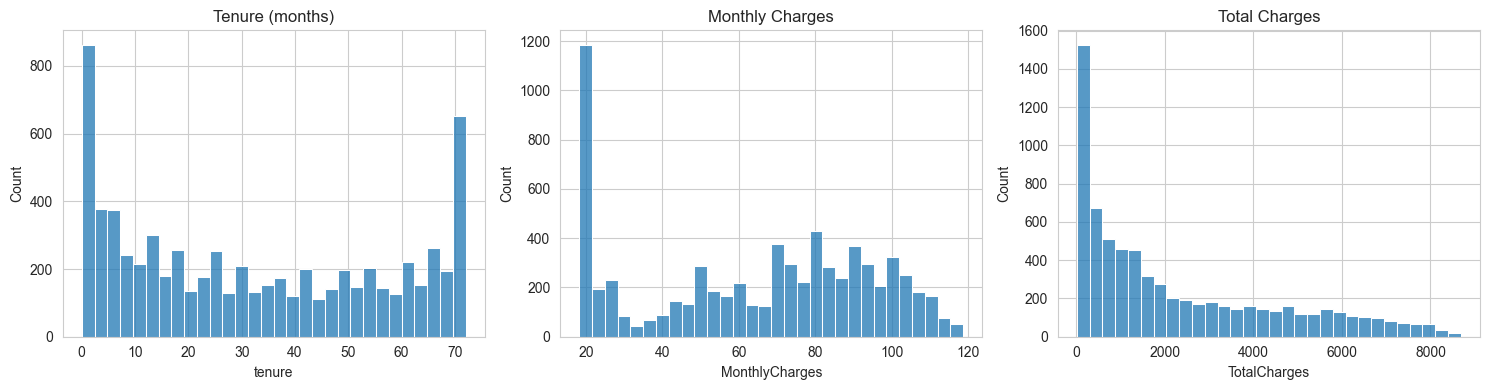

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(customer_data["tenure"], bins=30, ax=axes[0])
axes[0].set_title("Tenure (months)")

sns.histplot(customer_data["MonthlyCharges"], bins=30, ax=axes[1])
axes[1].set_title("Monthly Charges")

sns.histplot(customer_data["TotalCharges"].dropna(), bins=30, ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout()
plt.show()

**What are we looking at?** `tenure` is bimodal-ish — lots of very new
customers (near 0) and lots of long-tenured ones (near 70+), fewer in
between. `MonthlyCharges` is spread fairly widely with a cluster near the
low end (customers with no internet service pay less). `TotalCharges` is
right-skewed, which makes sense: it's roughly `tenure × MonthlyCharges`, so
it inherits skew from both.

**Does this imply causation?** No — this only describes the *shape* of each
feature on its own, not any relationship to churn yet.

### Question: Is the target itself balanced?

We already answered this numerically in notebook 01; here's the same fact
as a count plot, since visual and numeric summaries reinforce each other.

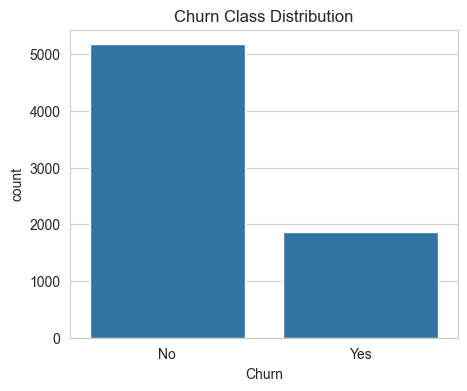

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=customer_data, x="Churn")
plt.title("Churn Class Distribution")
plt.show()

## 7. Bivariate Analysis — Feature vs. Target

### Question: Does contract type appear to influence churn?

Business intuition: month-to-month customers can leave anytime with no
penalty, so we'd expect them to churn more than customers locked into
1- or 2-year contracts.

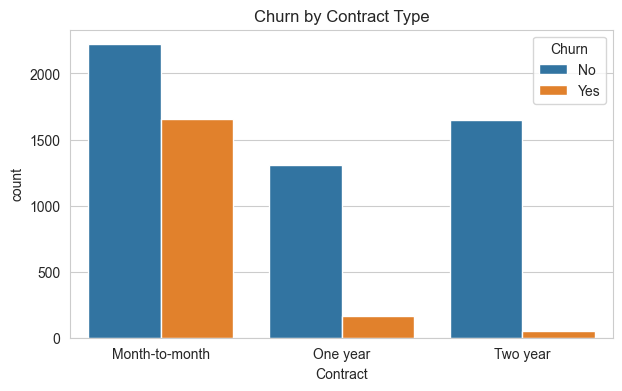

Churn rate by contract type (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [5]:
plt.figure(figsize=(7, 4))
sns.countplot(data=customer_data, x="Contract", hue="Churn", order=["Month-to-month", "One year", "Two year"])
plt.title("Churn by Contract Type")
plt.show()

contract_churn_rate = (
    customer_data.groupby("Contract")["Churn"]
    .apply(lambda churn_values: (churn_values == "Yes").mean() * 100)
    .reindex(["Month-to-month", "One year", "Two year"])
)
print("Churn rate by contract type (%):")
print(contract_churn_rate.round(1))

**What pattern do we see?** Month-to-month customers churn at a much
higher rate than one-year or two-year contract customers.

**Why might this pattern exist?** Longer contracts likely have cancellation
friction (fees, commitment) and self-select customers who intend to stay
longer in the first place.

**Does this imply causation?** Not proven — it's plausible that contract
length *causes* lower churn (via switching cost), but it's also plausible
that customers who were already going to stay longer *chose* longer
contracts. We can't distinguish these from observational data alone.

**How could this affect our model?** `Contract` is very likely to become one
of the most important features for a decision tree — trees naturally look
for exactly this kind of clean split.

### Question: Does having no internet service relate to churn differently than the type of internet service?

We'd expect fiber optic (typically pricier, sometimes less reliable in this
dataset) to behave differently than DSL or no internet at all.

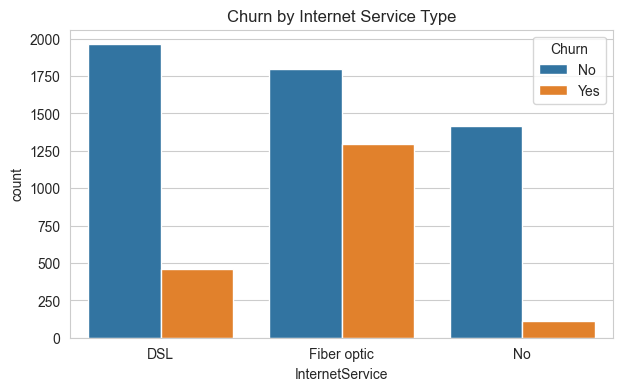

Churn rate by internet service (%):
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


In [6]:
plt.figure(figsize=(7, 4))
sns.countplot(data=customer_data, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service Type")
plt.show()

internet_churn_rate = (
    customer_data.groupby("InternetService")["Churn"]
    .apply(lambda churn_values: (churn_values == "Yes").mean() * 100)
)
print("Churn rate by internet service (%):")
print(internet_churn_rate.round(1))

**What pattern do we see?** Fiber optic customers churn at a
noticeably higher rate than DSL or no-internet customers.

**Why might this pattern exist?** Fiber is the most expensive tier in this
dataset (we'll confirm with monthly charges below) — price sensitivity is a
plausible driver, though service quality complaints could be a factor too;
we can't tell which from this data alone.

### Question: Do customers who churn pay more per month?

Numerical feature vs. categorical target — a box plot is the right tool
here since it directly compares distributions across groups.

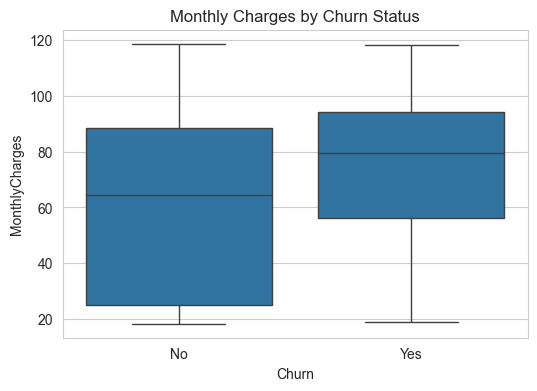

Churn
No     64.425
Yes    79.650
Name: MonthlyCharges, dtype: float64

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=customer_data, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

customer_data.groupby("Churn")["MonthlyCharges"].median()

**What pattern do we see?** Customers who churn have a visibly higher
median monthly charge than those who stay.

**How could this affect our model?** Combined with the contract and
internet-service findings, a coherent story emerges: higher-priced,
no-commitment customers churn more. A decision tree should be able to
recover this pattern from splits on `MonthlyCharges` and `Contract` even
without us telling it this story explicitly.

### Question: Does tenure differ between customers who churn and who don't?

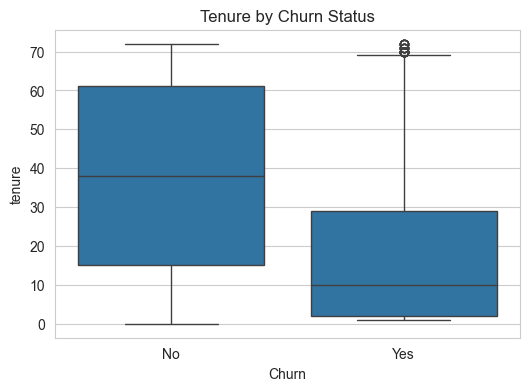

Churn
No     38.0
Yes    10.0
Name: tenure, dtype: float64

In [8]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=customer_data, x="Churn", y="tenure")
plt.title("Tenure by Churn Status")
plt.show()

customer_data.groupby("Churn")["tenure"].median()

**What pattern do we see?** Churned customers have much lower median
tenure. This is intuitive — customers who are going to leave often do so
early, and customers who've stuck around a long time have already
demonstrated they don't churn easily (survivorship).

## 8. Multivariate Analysis

### Question: Are our three numerical features correlated with each other?

If `TotalCharges` is almost perfectly explained by `tenure` and
`MonthlyCharges`, that's useful to know before feature engineering — adding
a feature that's just a near-duplicate of two others adds little signal but
does add redundancy.

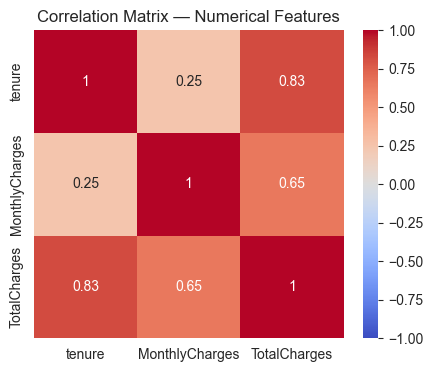

,tenure,MonthlyCharges,TotalCharges
tenure,1.00000,0.247900,0.825880
MonthlyCharges,0.24790,1.000000,0.651065
TotalCharges,0.82588,0.651065,1.000000


In [9]:
correlation_matrix = customer_data[["tenure", "MonthlyCharges", "TotalCharges"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix — Numerical Features")
plt.show()

correlation_matrix

**What are we looking at?** `TotalCharges` correlates very strongly
with `tenure` (long-tenured customers have accumulated more total charges)
and moderately with `MonthlyCharges`. This confirms the relationship we
guessed at in the univariate section.

**Why does this matter for modeling?** Highly correlated numerical features
are less of a problem for decision trees (which split on one feature at a
time) than for linear models, but it's still useful context: if
`TotalCharges` were dropped entirely, `tenure` × `MonthlyCharges` still
carries most of the same information.

## 9. Interpretation — Summary of Findings

| Finding | Business Interpretation |
|---|---|
| Month-to-month contracts churn far more than 1–2 year contracts | Contract length / commitment reduces churn (or correlates with intent to stay) |
| Fiber optic internet customers churn more than DSL/no-internet | Price and/or service quality on fiber may drive churn |
| Churned customers have higher median monthly charges | Price sensitivity is a plausible churn driver |
| Churned customers have lower median tenure | Churn risk is concentrated in newer customers |
| `TotalCharges` ≈ f(`tenure`, `MonthlyCharges`) | Expected redundancy, not a data error |

None of these prove causation on their own — they are patterns a model can
exploit for prediction, and starting points for a human to investigate
further (e.g. "why do fiber customers churn more — price or quality?").

## 10. Common Mistakes

- **Plotting everything against everything.** Without a question driving
  each plot, you generate noise and are prone to seeing patterns that aren't
  really there (multiple-comparisons problem).
- **Treating a strong bivariate pattern as proof of causation.** "Month-to-
  month customers churn more" does not by itself prove that *switching to* a
  longer contract *would cause* an individual customer to stay.
- **Forgetting `TotalCharges` still has NaNs here** (from the `errors="coerce"`
  step) — any aggregate that doesn't call `.dropna()` or isn't NaN-aware
  (like `.corr()`, which handles NaNs automatically, versus manual numpy
  operations, which often don't) can silently produce wrong numbers.

## 11. What We Learned

- Contract type, internet service type, monthly charges, and tenure all show
  a visible relationship with churn.
- The overall story: newer, higher-paying, no-commitment customers are the
  highest churn risk — a coherent, business-explainable pattern.
- `TotalCharges` is largely redundant with `tenure` and `MonthlyCharges`,
  which will matter when we decide what to feed into the model later.

## 12. Exercises

1. Make a count plot of `Churn` by `PaymentMethod`. Which payment method has
   the highest churn rate? Can you think of a business reason why?
2. Does `SeniorCitizen` (0/1) show a different churn rate than non-senior
   customers? Compute the churn rate for each group.
3. We found fiber optic customers churn more. Now check: do fiber optic
   customers also have higher `MonthlyCharges` than DSL customers? Does that
   change your interpretation of *why* they churn more?
4. Pick one relationship from this notebook and write, in 2–3 sentences, a
   plausible *non-causal* explanation for the pattern (i.e., a confound) —
   practice the "does this imply causation?" habit explicitly.